<a href="https://colab.research.google.com/github/Snehagupta-133/Solar-Power-Generation-Prediction-using-ML/blob/main/Solar%20Power%20Generation%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving THDi,PF,KVA April 24.csv to THDi,PF,KVA April 24.csv


In [ ]:
import pandas as pd
df = pd.read_csv("THDi,PF,KVA April 24.csv")

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Unnamed: 1', 'Date ', 'Time', 'IRR', 'Temp', '%RH',
       'THDi', 'Unnamed: 8', 'PF', 'KVA', 'Unnamed: 11'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [ ]:
print(df.columns)

Index(['Date', 'Time', 'IRR', 'Temp', '%RH', 'THDi', 'PF', 'KVA'], dtype='object')


In [ ]:
df.shape

(351, 8)

In [ ]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="mixed"
)

In [ ]:
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month

In [ ]:
print(df.columns)

Index(['Date', 'Time', 'IRR', 'Temp', '%RH', 'THDi', 'PF', 'KVA', 'datetime',
       'hour', 'minute', 'day', 'month'],
      dtype='object')


In [ ]:
df.head()


,Date,Time,IRR,Temp,%RH,THDi,PF,KVA,datetime,hour,minute,day,month
0,04/18/2024,11:10:00,933.560087,35.198879,41.188351,7.0,0.993,57.37,2024-04-18 11:10:00,11,10,18,4
1,04/18/2024,11:12:00,935.042317,35.234770,41.034793,7.0,0.994,57.99,2024-04-18 11:12:00,11,12,18,4
2,04/18/2024,11:14:00,936.448233,35.269592,40.883983,6.9,0.994,59.01,2024-04-18 11:14:00,11,14,18,4
3,04/18/2024,11:16:00,937.777956,35.303444,40.735846,7.0,0.994,59.20,2024-04-18 11:16:00,11,16,18,4
4,04/18/2024,11:18:00,939.031608,35.336424,40.590305,6.9,0.994,59.16,2024-04-18 11:18:00,11,18,18,4


In [ ]:
df.shape

(351, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      351 non-null    object        
 1   Time      351 non-null    object        
 2   IRR       351 non-null    float64       
 3   Temp      351 non-null    float64       
 4   %RH       351 non-null    float64       
 5   THDi      351 non-null    float64       
 6   PF        351 non-null    float64       
 7   KVA       351 non-null    float64       
 8   datetime  351 non-null    datetime64[ns]
 9   hour      351 non-null    int32         
 10  minute    351 non-null    int32         
 11  day       351 non-null    int32         
 12  month     351 non-null    int32         
dtypes: datetime64[ns](1), float64(6), int32(4), object(2)
memory usage: 30.3+ KB


In [ ]:
df.describe()

,IRR,Temp,%RH,THDi,PF,KVA,datetime,hour,minute,day,month
count,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351,351.000000,351.000000,351.000000,351.0
mean,584.388746,31.040785,52.747673,37.486895,0.910641,36.540359,2024-04-18 21:56:36.581196544,11.547009,28.917379,18.413105,4.0
min,8.000000,20.000000,36.000000,6.000000,-0.014000,4.361000,2024-04-18 11:10:00,6.000000,0.000000,18.000000,4.0
25%,330.042320,28.280706,39.574538,9.200000,0.894000,13.070000,2024-04-18 14:05:00,8.000000,14.000000,18.000000,4.0
50%,640.534369,31.800246,50.058494,13.400000,0.984000,38.240000,2024-04-18 17:00:00,12.000000,28.000000,18.000000,4.0
75%,860.164682,35.415626,63.554808,44.950000,0.991000,53.100000,2024-04-19 07:53:00,15.000000,44.000000,19.000000,4.0
max,948.843012,37.003947,83.000000,723.900000,0.995000,624.000000,2024-04-19 10:48:00,18.000000,58.000000,19.000000,4.0
std,295.119738,4.737325,13.962122,70.569009,0.158618,38.682130,NaN,3.512823,17.103768,0.493094,0.0


In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
IRR,0
Temp,0
%RH,0
THDi,0
PF,0
KVA,0
datetime,0
hour,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(df.columns)

Index(['Date', 'Time', 'IRR', 'Temp', '%RH', 'THDi', 'PF', 'KVA', 'datetime',
       'hour', 'minute', 'day', 'month'],
      dtype='object')


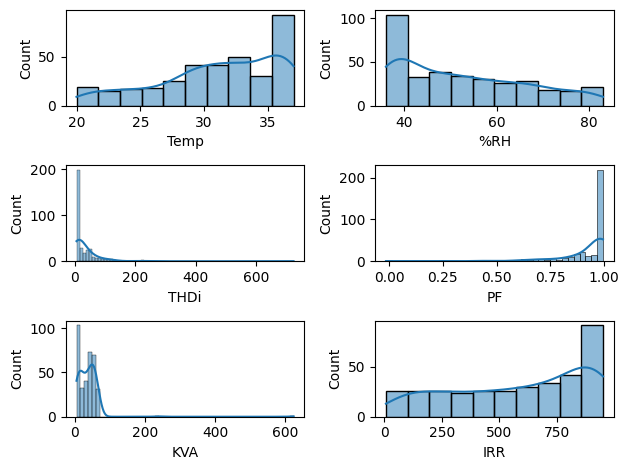

In [ ]:
def plotting(var, num):
  plt.subplot(3,2,num)
  sns.histplot(df[var], kde=True)

plotting('Temp',1)
plotting('%RH',2)
plotting('THDi',3)
plotting('PF',4)
plotting('KVA',5)
plotting('IRR',6)

plt.tight_layout()

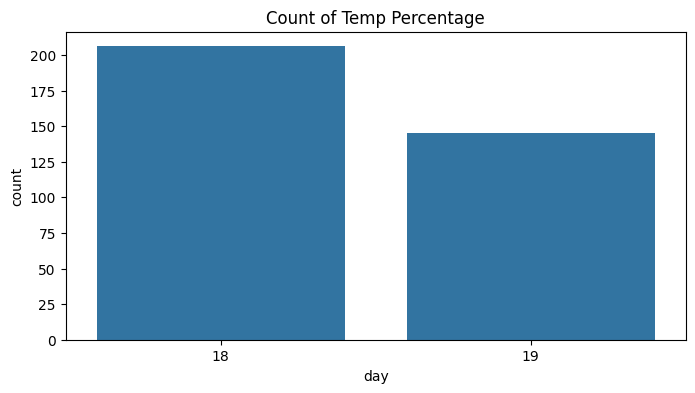

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x="day", data=df)
plt.title("Count of Temp Percentage")
plt.show()

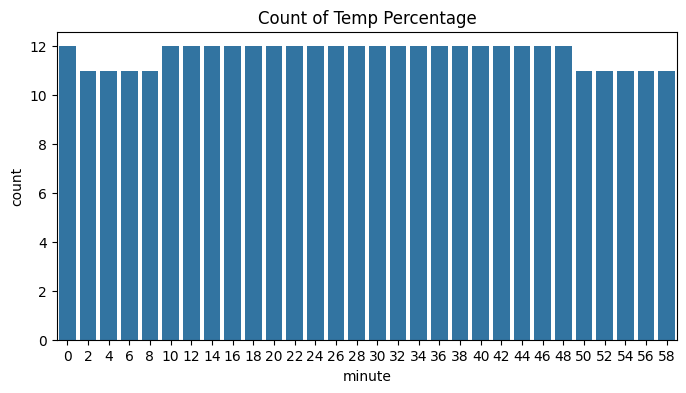

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x="minute", data=df)
plt.title("Count of Temp Percentage")
plt.show()

In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Date : 2
Time : 351
IRR : 351
Temp : 349
%RH : 350
THDi : 216
PF : 141
KVA : 340
datetime : 351
hour : 13
minute : 30
day : 2
month : 1


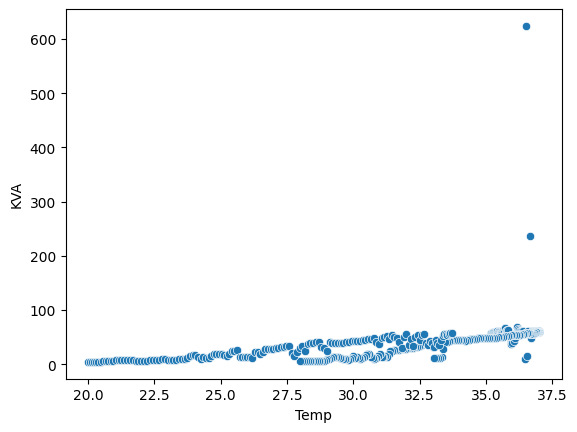

In [ ]:
sns.scatterplot(x="Temp", y="KVA", data=df)
plt.show()


In [ ]:
df[df["THDi"] > 200]


,Date,Time,IRR,Temp,%RH,THDi,PF,KVA,datetime,hour,minute,day,month
206,04/19/2024,06:00:00 AM,50.000000,20.000000,83.000000,723.9,0.125,4.361,2024-04-19 06:00:00,6,0,19,4
207,04/19/2024,06:02:00 AM,56.511909,20.071196,82.782075,685.5,0.171,4.370,2024-04-19 06:02:00,6,2,19,4
208,04/19/2024,06:04:00 AM,63.084603,20.145756,82.565100,539.8,0.238,4.435,2024-04-19 06:04:00,6,4,19,4
209,04/19/2024,06:06:00 AM,69.716408,20.223533,82.348861,356.0,0.333,4.617,2024-04-19 06:06:00,6,6,19,4
210,04/19/2024,06:08:00 AM,76.405649,20.304379,82.133141,254.0,0.418,4.882,2024-04-19 06:08:00,6,8,19,4
211,04/19/2024,06:10:00 AM,83.150651,20.388147,81.917724,219.4,0.455,5.039,2024-04-19 06:10:00,6,10,19,4
212,04/19/2024,06:12:00 AM,89.949740,20.474688,81.702396,213.9,0.457,5.040,2024-04-19 06:12:00,6,12,19,4
213,04/19/2024,06:14:00 AM,96.801241,20.563856,81.486940,222.5,0.454,5.156,2024-04-19 06:14:00,6,14,19,4


In [ ]:
df[df["PF"] < 0.5]


,Date,Time,IRR,Temp,%RH,THDi,PF,KVA,datetime,hour,minute,day,month
36,04/18/2024,12:22:00,939.660689,36.457797,36.909137,44.8,0.183,10.140,2024-04-18 12:22:00,12,22,18,4
37,04/18/2024,12:24:00,938.458159,36.499829,36.823946,50.4,0.000,624.000,2024-04-18 12:24:00,12,24,18,4
38,04/18/2024,12:26:00,937.181187,36.541251,36.741873,40.9,0.243,14.820,2024-04-18 12:26:00,12,26,18,4
41,04/18/2024,12:32:00,932.902769,36.660284,36.516182,45.5,-0.014,237.000,2024-04-18 12:32:00,12,32,18,4
206,04/19/2024,06:00:00 AM,50.000000,20.000000,83.000000,723.9,0.125,4.361,2024-04-19 06:00:00,6,0,19,4
207,04/19/2024,06:02:00 AM,56.511909,20.071196,82.782075,685.5,0.171,4.370,2024-04-19 06:02:00,6,2,19,4
208,04/19/2024,06:04:00 AM,63.084603,20.145756,82.565100,539.8,0.238,4.435,2024-04-19 06:04:00,6,4,19,4
209,04/19/2024,06:06:00 AM,69.716408,20.223533,82.348861,356.0,0.333,4.617,2024-04-19 06:06:00,6,6,19,4
210,04/19/2024,06:08:00 AM,76.405649,20.304379,82.133141,254.0,0.418,4.882,2024-04-19 06:08:00,6,8,19,4
211,04/19/2024,06:10:00 AM,83.150651,20.388147,81.917724,219.4,0.455,5.039,2024-04-19 06:10:00,6,10,19,4


In [ ]:
df[df["KVA"] > 150]


,Date,Time,IRR,Temp,%RH,THDi,PF,KVA,datetime,hour,minute,day,month
37,04/18/2024,12:24:00,938.458159,36.499829,36.823946,50.4,0.000,624.0,2024-04-18 12:24:00,12,24,18,4
41,04/18/2024,12:32:00,932.902769,36.660284,36.516182,45.5,-0.014,237.0,2024-04-18 12:32:00,12,32,18,4


In [ ]:
df_clean = df[
    (df["THDi"] <= 200) &
    (df["PF"] >= 0.5) &
    (df["KVA"] <= 150)
]


In [ ]:
print(df.shape)
print(df_clean.shape)

print(df_clean[df_clean["THDi"] > 200])
print(df_clean[df_clean["PF"] < 0.5])
print(df_clean[df_clean["KVA"] > 150])


(351, 13)
(339, 13)
Empty DataFrame
Columns: [Date, Time, IRR, Temp, %RH, THDi, PF, KVA, datetime, hour, minute, day, month]
Index: []
Empty DataFrame
Columns: [Date, Time, IRR, Temp, %RH, THDi, PF, KVA, datetime, hour, minute, day, month]
Index: []
Empty DataFrame
Columns: [Date, Time, IRR, Temp, %RH, THDi, PF, KVA, datetime, hour, minute, day, month]
Index: []


<Axes: xlabel='Temp', ylabel='KVA'>

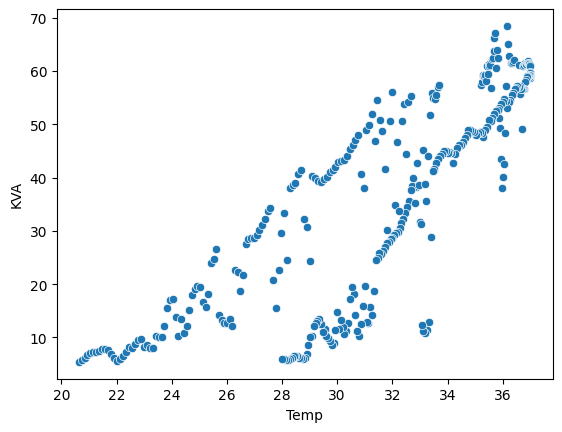

In [ ]:
sns.scatterplot(x="Temp", y="KVA", data=df_clean)

In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
IRR,0
Temp,0
%RH,0
THDi,0
PF,0
KVA,0
datetime,0
hour,0


<Axes: >

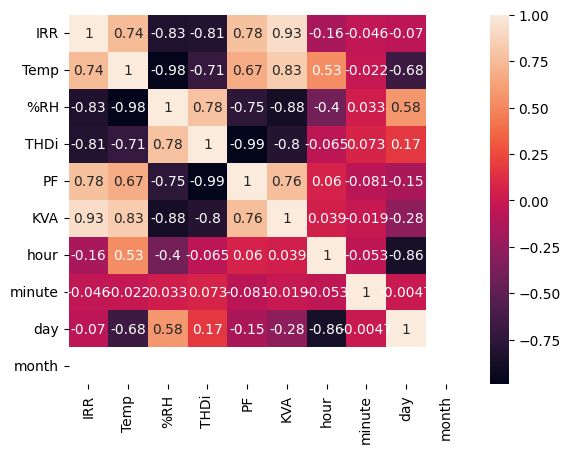

In [ ]:
sns.heatmap(df_clean.corr(numeric_only=True), annot=True)

In [ ]:
X = df_clean[["IRR", "Temp", "%RH", "hour", "minute", "day"]]
y = df_clean[["THDi", "PF", "KVA"]]

<Axes: >

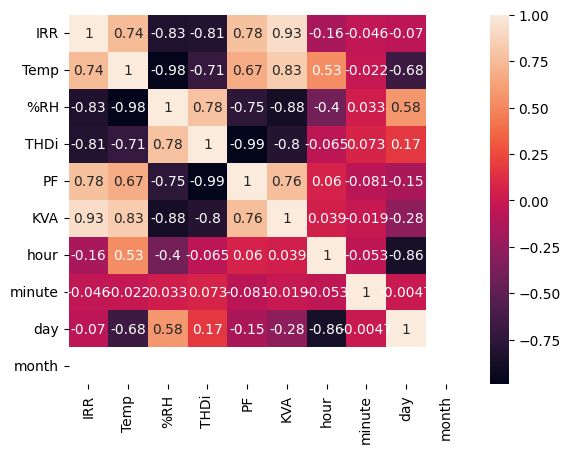

In [ ]:
sns.heatmap(df_clean.corr(numeric_only=True), annot=True)

In [ ]:
X = df_clean[["IRR", "Temp", "%RH", "hour", "minute", "day"]]
y = df_clean[["THDi", "PF", "KVA"]]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", MultiOutputRegressor(
        SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
    ))
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svr', MultiOutputRegressor(estimator=SVR(C=100)))])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
r2 = r2_score(y_test, y_pred, multioutput="raw_values")

accuracy_results = pd.DataFrame({
    "Output": ["THDi", "PF", "KVA"],
    "MAE": mae,
    "RMSE": rmse,
    "R2_Score": r2,
    "Performance_%": r2 * 100
})

accuracy_results


,Output,MAE,RMSE,R2_Score,Performance_%
0,THDi,4.314154,9.747692,0.872948,87.294833
1,PF,0.072441,0.076468,0.154296,15.429583
2,KVA,2.970283,5.438777,0.914057,91.405734


In [ ]:
accuracy_results["Accuracy_%"] = accuracy_results["R2_Score"] * 100
accuracy_results


,Output,MAE,RMSE,R2_Score,Performance_%,Accuracy_%
0,THDi,4.314154,9.747692,0.872948,87.294833,87.294833
1,PF,0.072441,0.076468,0.154296,15.429583,15.429583
2,KVA,2.970283,5.438777,0.914057,91.405734,91.405734


In [ ]:
X = df_clean[["IRR", "Temp", "%RH"]]
y = df_clean[["THDi", "PF", "KVA"]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", MultiOutputRegressor(
        SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
r2 = r2_score(y_test, y_pred, multioutput="raw_values")

accuracy_results = pd.DataFrame({
    "Output": ["THDi", "PF", "KVA"],
    "MAE": mae,
    "RMSE": rmse,
    "R2_Score": r2,
    "Performance_%": r2 * 100
})

accuracy_results

,Output,MAE,RMSE,R2_Score,Performance_%
0,THDi,4.842187,10.040156,0.865210,86.520998
1,PF,0.069332,0.073391,0.220983,22.098289
2,KVA,3.315022,6.197283,0.888414,88.841420


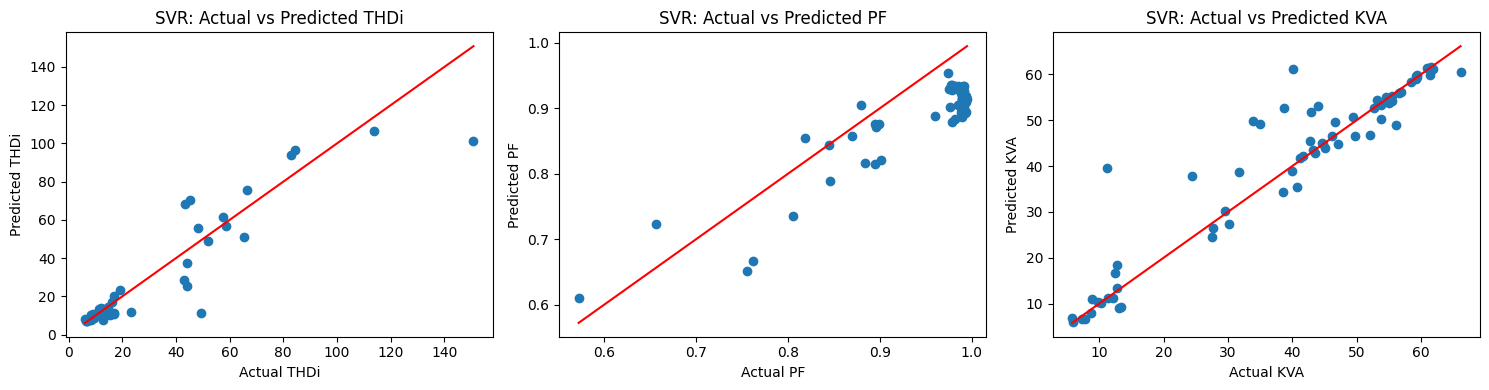

In [ ]:
import matplotlib.pyplot as plt

outputs = ["THDi", "PF", "KVA"]

plt.figure(figsize=(15, 4))

for i, output in enumerate(outputs):
    plt.subplot(1, 3, i + 1)

    plt.scatter(y_test[output], y_pred[:, i])
    plt.xlabel("Actual " + output)
    plt.ylabel("Predicted " + output)
    plt.title("SVR: Actual vs Predicted " + output)

    min_val = min(y_test[output].min(), y_pred[:, i].min())
    max_val = max(y_test[output].max(), y_pred[:, i].max())

    plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X = df_clean[["IRR", "Temp", "%RH"]]
y = df_clean[["THDi", "PF", "KVA"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)


In [ ]:
mae_knn = mean_absolute_error(y_test, y_pred_knn, multioutput="raw_values")
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn, multioutput="raw_values"))
r2_knn = r2_score(y_test, y_pred_knn, multioutput="raw_values")

knn_results = pd.DataFrame({
    "Output": ["THDi", "PF", "KVA"],
    "MAE": mae_knn,
    "RMSE": rmse_knn,
    "R2_Score": r2_knn,
    "Performance_%": r2_knn * 100
})

knn_results


,Output,MAE,RMSE,R2_Score,Performance_%
0,THDi,2.920588,5.865112,0.954003,95.400301
1,PF,0.009315,0.017885,0.953734,95.373440
2,KVA,2.433379,4.165371,0.949590,94.959036


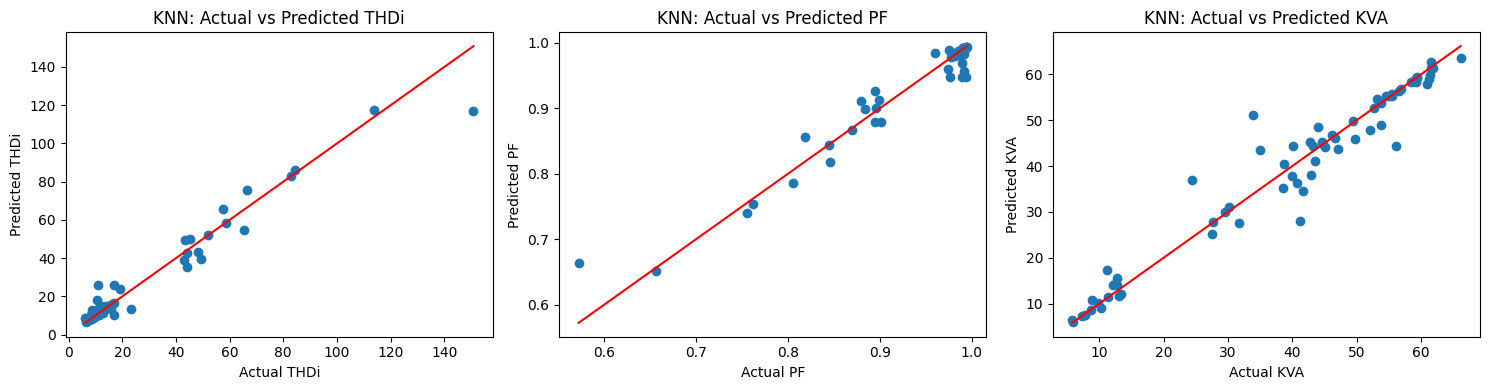

In [ ]:
outputs = ["THDi", "PF", "KVA"]

plt.figure(figsize=(15, 4))

for i, output in enumerate(outputs):
    plt.subplot(1, 3, i + 1)

    plt.scatter(y_test[output], y_pred_knn[:, i])
    plt.xlabel("Actual " + output)
    plt.ylabel("Predicted " + output)
    plt.title("KNN: Actual vs Predicted " + output)

    min_val = min(y_test[output].min(), y_pred_knn[:, i].min())
    max_val = max(y_test[output].max(), y_pred_knn[:, i].max())

    plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


In [ ]:
X = df_clean[["IRR", "Temp", "%RH"]]
y = df_clean[["THDi", "PF", "KVA"]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf, multioutput="raw_values")
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf, multioutput="raw_values"))
r2_rf = r2_score(y_test, y_pred_rf, multioutput="raw_values")

rf_results = pd.DataFrame({
    "Output": ["THDi", "PF", "KVA"],
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "R2_Score": r2_rf,
    "Performance_%": r2_rf * 100
})

rf_results


,Output,MAE,RMSE,R2_Score,Performance_%
0,THDi,2.201103,3.696994,0.981724,98.172429
1,PF,0.006779,0.013293,0.974441,97.444115
2,KVA,2.118386,4.002994,0.953444,95.344396


In [ ]:
y_pred_rf = rf_model.predict(X_test)


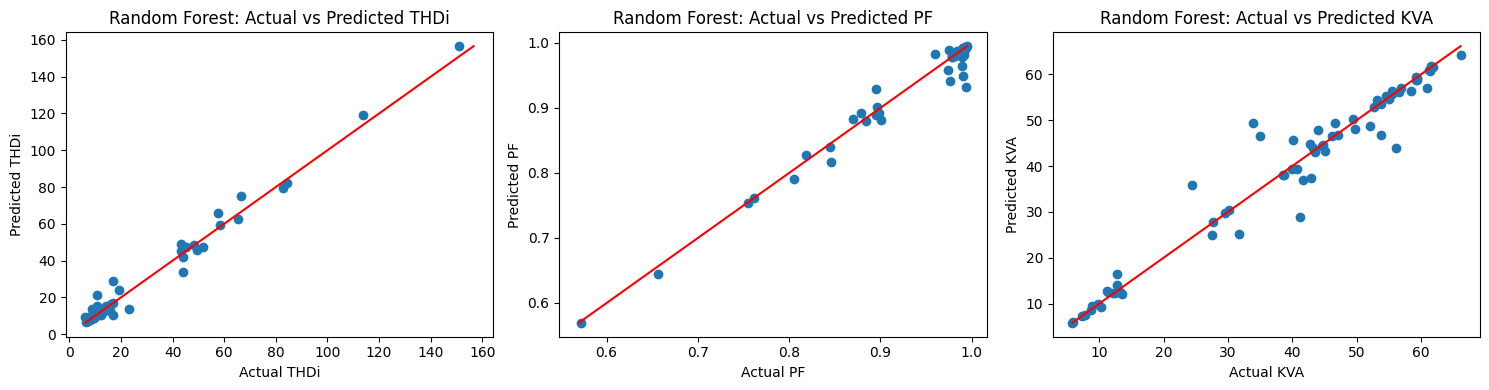

In [ ]:
import matplotlib.pyplot as plt

outputs = ["THDi", "PF", "KVA"]

plt.figure(figsize=(15, 4))

for i, output in enumerate(outputs):
    plt.subplot(1, 3, i + 1)

    plt.scatter(y_test[output], y_pred_rf[:, i])
    plt.xlabel("Actual " + output)
    plt.ylabel("Predicted " + output)
    plt.title("Random Forest: Actual vs Predicted " + output)

    min_val = min(y_test[output].min(), y_pred_rf[:, i].min())
    max_val = max(y_test[output].max(), y_pred_rf[:, i].max())

    plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.tight_layout()
plt.show()
